In [4]:
import xarray as xr
import numpy as np  # Importieren wir für die Prüfung
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

filepath = "../../output/hrrr_mini_generierte_daten.nc"
# 1. Koordinaten laden
ds_coords = xr.open_dataset(filepath, engine='h5netcdf')

# 2. Daten laden
ds_input = xr.open_dataset(filepath, group='input', engine='h5netcdf')

# 3. Koordinaten BEREINIGEN
# Wir füllen alle NaN-Werte (non-finite) in lon und lat mit 0
# .fillna(0) ist die xarray-Methode dafür
clean_lon = ds_coords.lon.fillna(0)
clean_lat = ds_coords.lat.fillna(0)

# 4. Die BEREINIGTEN Koordinaten zuweisen
ds_input = ds_input.assign_coords(
    lon=(("y", "x"), clean_lon.data),
    lat=(("y", "x"), clean_lat.data)
)

# Kurze Gegenprüfung, ob die NaNs weg sind:
print("NaNs in lon nach Bereinigung:", np.isnan(ds_input.lon.data).any())
print("NaNs in lat nach Bereinigung:", np.isnan(ds_input.lat.data).any())
# Hier sollte jetzt 'False' stehen.

NaNs in lon nach Bereinigung: False
NaNs in lat nach Bereinigung: False


/home/daniel/.virtualenvs/corrdiff/lib/python3.10/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


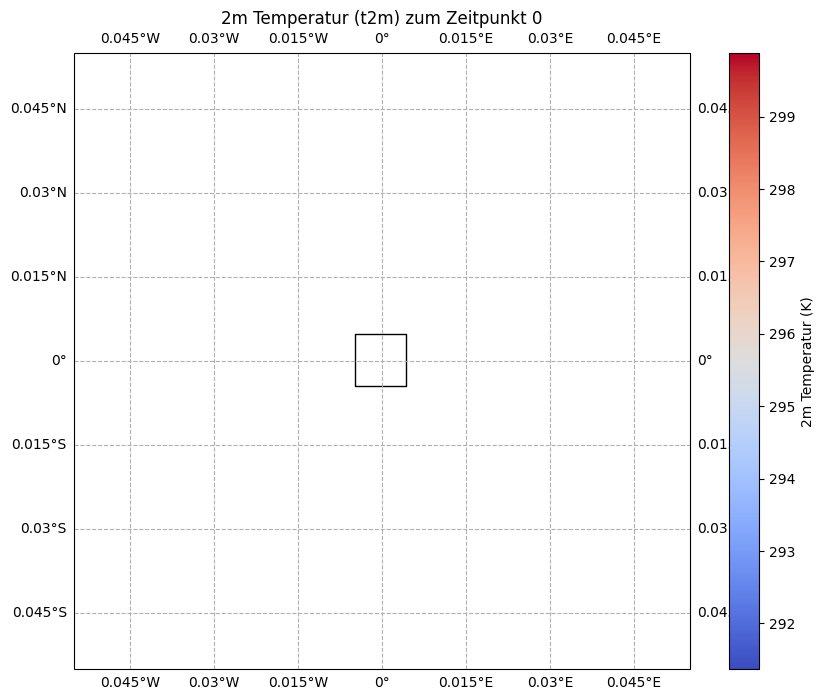

In [5]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# Wähle die Variable und einen Zeitschritt aus
t2m_data = ds_input['t2m'].isel(time=0)

# Erstelle die Karte
fig = plt.figure(figsize=(10, 8))
# Wähle eine Projektion, z.B. PlateCarree (Standard-Lat/Lon) oder LambertConformal
ax = plt.axes(projection=ccrs.PlateCarree())

# Plotte die Daten
# WICHTIG:
# x='lon', y='lat' -> Sagt xarray, welche Koordinaten es nutzen soll
# transform=ccrs.PlateCarree() -> Sagt cartopy, dass die Daten in Lat/Lon-Koordinaten vorliegen
t2m_data.plot.pcolormesh(
    ax=ax,
    x='lon',
    y='lat',
    transform=ccrs.PlateCarree(),
    cmap='coolwarm',  # Ein gängiges Farbschema für Temperatur
    cbar_kwargs={'label': '2m Temperatur (K)'} # Annahme: Kelvin
)



# Füge Features hinzu
ax.coastlines()
ax.gridlines(draw_labels=True, linestyle='--')

plt.title('2m Temperatur (t2m) zum Zeitpunkt 0')
plt.show()

In [6]:
# Lade die Koordinaten noch einmal im Original, nur um die Grenzen zu prüfen
ds_coords_check = xr.open_dataset(filepath, engine='h5netcdf')

# Finde die echten Grenzen, indem wir NaNs ignorieren
# .item() wandelt das Ergebnis in eine einfache Zahl um
min_lon = ds_coords_check.lon.min(skipna=True).item()
max_lon = ds_coords_check.lon.max(skipna=True).item()
min_lat = ds_coords_check.lat.min(skipna=True).item()
max_lat = ds_coords_check.lat.max(skipna=True).item()

print(f"Deine Kartengrenzen (Extent) sind:")
print(f"lon: [{min_lon}, {max_lon}]")
print(f"lat: [{min_lat}, {max_lat}]")

# Erstelle ein Array für den set_extent Befehl
# WICHTIG: Die Reihenfolge ist [west, ost, süd, nord]
map_extent = [min_lon, max_lon, min_lat, max_lat]
print(f"\nKopiere diese Zeile in den Plot-Code: \nax.set_extent({map_extent}, crs=ccrs.PlateCarree())")

Deine Kartengrenzen (Extent) sind:
lon: [nan, nan]
lat: [nan, nan]

Kopiere diese Zeile in den Plot-Code: 
ax.set_extent([nan, nan, nan, nan], crs=ccrs.PlateCarree())


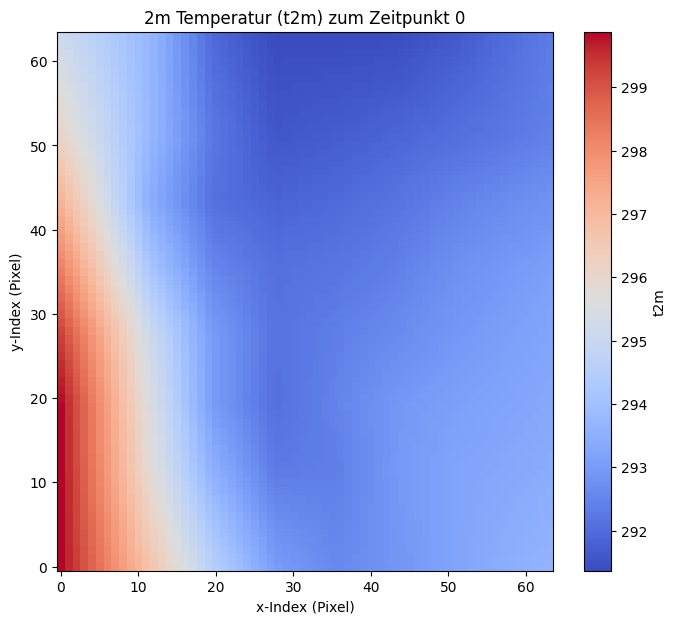

In [7]:
filepath_gen = "../../output/hrrr_mini_generierte_daten.nc"

# Lade die Daten
ds_input = xr.open_dataset(filepath_gen, group='input', engine='h5netcdf')
t2m_data = ds_input['t2m'].isel(time=0)

# Erstelle einen einfachen Bild-Plot (keine Karte!)
plt.figure(figsize=(8, 7))

# .plot.imshow() nutzt die Array-Indizes (0-63) statt 'lon'/'lat'
t2m_data.plot.imshow(cmap='coolwarm')



plt.title('2m Temperatur (t2m) zum Zeitpunkt 0')
plt.xlabel('x-Index (Pixel)')
plt.ylabel('y-Index (Pixel)')
plt.show()

Originale Koordinaten-Dimensionen: (1059, 1799)
Ausgeschnittene Patch-Dimensionen: (64, 64)
NEUE (Dummy) Kartengrenzen (Extent) sind:
[-100.96111297607422, -98.73347473144531, 37.66575622558594, 39.40778732299805]


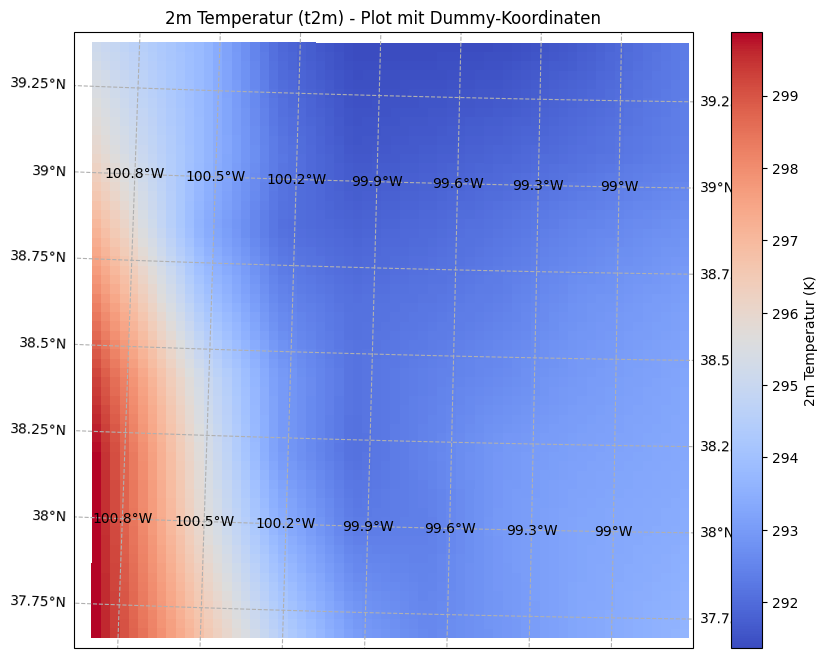

In [11]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# --- SCHRITT 1: Pfade definieren ---
# Pfad zu deinen kaputten, aber datenreichen Datei

filepath = "../hrrr_mini/hrrr_mini_generierte_daten.nc"


filepath_gen =   "../hrrr_mini/hrrr_mini_generierte_daten.nc"

# !! ERSETZE DIES !! Pfad zur originalen Datei mit den guten Koordinaten
filepath_orig_coords = "../hrrr_mini/hrrr_mini_train.nc"

# --- SCHRITT 2: Daten und Koordinaten getrennt laden ---
# Lade die Input-Daten (64x64)
ds_input = xr.open_dataset(filepath_gen, group='input', engine='h5netcdf')

# Lade die vollen Koordinaten (1059x1799) aus der 'invariant'-Gruppe
try:
    ds_coords_orig = xr.open_dataset(filepath_orig_coords, group='invariant', engine='h5netcdf')
except FileNotFoundError:
    print(f"Fehler: Konnte die Koordinaten-Datei nicht finden unter: {filepath_orig_coords}")
    raise

# --- SCHRITT 3: Einen 64x64 "Dummy"-Patch ausschneiden ---
print("Originale Koordinaten-Dimensionen:", ds_coords_orig.longitude.shape)

# Wähle einen 64x64-Ausschnitt, z.B. aus der Mitte des vollen Gitters
# Wir nehmen y=500 bis 564 und x=800 bis 864 (nur als Beispiel)
patch_lon = ds_coords_orig.longitude.isel(y_grid=slice(500, 564), x_grid=slice(800, 864))
patch_lat = ds_coords_orig.latitude.isel(y_grid=slice(500, 564), x_grid=slice(800, 864))

print("Ausgeschnittene Patch-Dimensionen:", patch_lon.shape)

# --- SCHRITT 4: Dimensionen umbenennen und "transplantieren" ---
# Benenne die Patch-Dimensionen um, damit sie zu den Daten-Dimensionen ('y', 'x') passen
patch_lon = patch_lon.rename({'y_grid': 'y', 'x_grid': 'x'})
patch_lat = patch_lat.rename({'y_grid': 'y', 'x_grid': 'x'})

# Weise die Dummy-Koordinaten dem Datensatz zu
ds_input = ds_input.assign_coords(
    lon=patch_lon,
    lat=patch_lat
)

# --- SCHRITT 5: Extent berechnen (sollte jetzt klappen) ---
min_lon = ds_input.lon.min().item()
max_lon = ds_input.lon.max().item()
min_lat = ds_input.lat.min().item()
max_lat = ds_input.lat.max().item()
map_extent = [min_lon, max_lon, min_lat, max_lat]

print(f"NEUE (Dummy) Kartengrenzen (Extent) sind:\n{map_extent}")

# --- SCHRITT 6: Plotten (mit set_extent) ---
t2m_data = ds_input['t2m'].isel(time=0)

fig = plt.figure(figsize=(10, 8))
# Wähle eine Projektion, die besser zur HRRR-Region (Nordamerika) passt
ax = plt.axes(projection=ccrs.LambertConformal(central_longitude=-97.5, central_latitude=38.5))

ax.set_extent(map_extent, crs=ccrs.PlateCarree()) # Extent ist immer in Lat/Lon

# Plotte die Daten
t2m_data.plot.pcolormesh(
    ax=ax,
    x='lon',
    y='lat',
    transform=ccrs.PlateCarree(), # Sag Cartopy, dass die Coords Lat/Lon sind
    cmap='coolwarm',
    cbar_kwargs={'label': '2m Temperatur (K)'}
)



ax.coastlines()
ax.gridlines(draw_labels=True, linestyle='--')
plt.title('2m Temperatur (t2m) - Plot mit Dummy-Koordinaten')
plt.show()